<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/0909)Seq2seq_translate_projct_last.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention 기반 Seq2Seq 한국어→영어 번역기 — MPS 개선

 숫자 `0~9` 보존, Attention의 PAD(패딩) 제외와 실제 문장 끝 은닉 상태 사용, `MAX_LEN=50` 및 잘림 비율 확인. 임베딩 512·은닉 1,024·어휘 15,000·드롭아웃 0.3·학습률 0.0005



In [ ]:
import os
import sys
import re
import tarfile
import urllib.request
import unicodedata

import numpy as np
import pandas as pd
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

# Colab은 CUDA, 지원하는 Mac은 MPS(Apple GPU), 그 외에는 CPU를 사용합니다.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('실행 장치:', device)

# Mac에서는 기본 한글 폰트로 어텐션 맵의 글자를 표시합니다.
if sys.platform == 'darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False


실행 장치: mps


## Step 1. 데이터 다운로드




In [ ]:
import os

try:
    from google.colab import drive
except ImportError:
    drive = None

if drive is not None:
    # 기존 파일과 충돌하지 않는 경로에 Google Drive를 연결합니다.
    mount_dir = '/content/seq2seq_drive'
    while os.path.lexists(mount_dir) and not os.path.ismount(mount_dir):
        mount_dir += '_new'
    drive.mount(mount_dir)
    project_dir = os.path.join(mount_dir, 'MyDrive', 'Aiffel_EPA', 's2s_translation')
else:
    # 로컬 Mac에서는 문서 폴더에 데이터를 저장하고 다음 실행에도 재사용합니다.
    project_dir = os.path.expanduser('~/Documents/Aiffel_EPA/s2s_translation')

dataset_dir = os.path.join(project_dir, 'datasets')
model_dir = os.path.join(project_dir, 'models')
os.makedirs(dataset_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
print('데이터 저장 위치:', dataset_dir)
print('SentencePiece 저장 위치:', model_dir)


데이터 저장 위치: /Users/yongza/Documents/Aiffel_EPA/s2s_translation/datasets
SentencePiece 저장 위치: /Users/yongza/Documents/Aiffel_EPA/s2s_translation/models


In [ ]:
url = ('https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/'
       'master/korean-english-news-v1/korean-english-park.train.tar.gz')


def load_parallel_corpus(url, dataset_dir):
    archive_path = os.path.join(dataset_dir, 'korean-english-park.train.tar.gz')
    filenames = ['korean-english-park.train.ko', 'korean-english-park.train.en']
    paths = [os.path.join(dataset_dir, name) for name in filenames]

    # 한영 파일이 모두 있으면 다운로드·압축 해제 없이 그대로 읽습니다.
    if not all(os.path.isfile(path) for path in paths):
        if not os.path.isfile(archive_path):
            print('데이터 다운로드 중:', dataset_dir)
            part_path = archive_path + '.part'
            urllib.request.urlretrieve(url, part_path)
            # 중간에 끊긴 파일을 완성 파일로 재사용하지 않도록 확인합니다.
            with tarfile.open(part_path, 'r:gz') as archive:
                archive.getmembers()
            os.replace(part_path, archive_path)

        with tarfile.open(archive_path, 'r:gz') as archive:
            members = {os.path.basename(m.name): m for m in archive.getmembers() if m.isfile()}
            for name, path in zip(filenames, paths):
                if not os.path.isfile(path):
                    # 필요한 두 파일만 저장하고, 쓰기가 끝나면 최종 이름으로 바꿉니다.
                    with archive.extractfile(members[name]) as src, open(path + '.part', 'wb') as dst:
                        dst.write(src.read())
                    os.replace(path + '.part', path)

    with open(paths[0], encoding='utf-8') as f:
        kor_lines = f.read().splitlines()
    with open(paths[1], encoding='utf-8') as f:
        eng_lines = f.read().splitlines()
    assert len(kor_lines) == len(eng_lines), '한국어와 영어의 줄 수를 확인하세요.'
    return kor_lines, eng_lines


kor_lines, eng_lines = load_parallel_corpus(url, dataset_dir)
print('문장 쌍:', len(kor_lines))
print('한국어:', kor_lines[0])
print('영어:', eng_lines[0])


문장 쌍: 94123
한국어: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
영어: Much of personal computing is about "can you top this?"


## Step 2. 데이터 정제




In [ ]:
def preprocess_english_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)          # 문장 부호 앞뒤에 공백
    sentence = re.sub(r"[^a-záéíóúñü0-9?.!,]+", " ", sentence)    # 글자·숫자·문장 부호를 남깁니다.
    sentence = re.sub(r"\s+", " ", sentence)                   # 연속 공백을 하나로

    sentence = sentence.strip()

    return sentence


def preprocess_korean_sentence(sentence):
    # 분리된 한글 자모도 완성형으로 합쳐서 가-힣 범위에 남깁니다.
    sentence = unicodedata.normalize('NFC', sentence).lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^가-힣a-záéíóúñü0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()


def prepare_parallel_corpus(kor_lines, eng_lines):
    assert len(kor_lines) == len(eng_lines), '한국어와 영어의 줄 수를 확인하세요.'
    # 쌍 전체를 set으로 확인하되, 리스트에는 원래 등장 순서대로 남깁니다.
    cleaned_corpus = []
    seen = set()
    for kor, eng in zip(kor_lines, eng_lines):
        pair = (kor.strip(), eng.strip())
        if pair not in seen:
            seen.add(pair)
            cleaned_corpus.append(pair)

    kor_corpus, eng_corpus = [], []
    for kor, eng in cleaned_corpus:
        kor = preprocess_korean_sentence(kor)
        eng = preprocess_english_sentence(eng)
        if 0 < len(kor.split()) <= 40 and 0 < len(eng.split()) <= 40:
            kor_corpus.append(kor)
            eng_corpus.append(eng)
    return cleaned_corpus, kor_corpus, eng_corpus


cleaned_corpus, kor_corpus, eng_corpus = prepare_parallel_corpus(kor_lines, eng_lines)
assert len(kor_corpus) == len(eng_corpus) > 0
assert '오바마' in preprocess_korean_sentence('오바마는 대통령이다.')
assert '7' in preprocess_korean_sentence('7명이 사망했다.')
assert '2026' in preprocess_english_sentence('The year is 2026.')
print('중복 제거 전:', len(kor_lines))
print('쌍 중복 제거 후:', len(cleaned_corpus))
print('정제·40어절 이하 필터 후:', len(kor_corpus))
df = pd.DataFrame({'kor': kor_corpus, 'eng': eng_corpus})
display(df.head())


중복 제거 전: 94123
쌍 중복 제거 후: 78941
정제·40어절 이하 필터 후: 71449


,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,"79 . 95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


## Step 3. 학습·검증 분리와 토큰화

한국어 문장 종류를 기준으로 학습 약 90%·검증 약 10%로 나눕니다(`VAL_RATIO=0.1`, `SPLIT_SEED=42`).

SentencePiece는 학습 데이터만 사용해 한국어·영어 어휘를 각각 20,000개로 학습합니다.


In [ ]:
vocab_size = 20000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3
MAX_LEN = 50  # 아래 잘림 비율 표를 보고 조절합니다.
BATCH_SIZE = 64
VAL_RATIO = 0.1
SPLIT_SEED = 42

# 같은 한국어 문장의 여러 번역은 한쪽에 모아 검증 데이터 누출을 막습니다.
train_sentences, val_sentences = train_test_split(
    df['kor'].unique(), test_size=VAL_RATIO, random_state=SPLIT_SEED
)
train_df = df[df['kor'].isin(train_sentences)].reset_index(drop=True)
val_df = df[df['kor'].isin(val_sentences)].reset_index(drop=True)
assert set(train_df['kor']).isdisjoint(set(val_df['kor']))
assert len(train_df) + len(val_df) == len(df)
print(f'학습: {len(train_df):,}쌍 / 검증: {len(val_df):,}쌍')


def tokenize(corpus, model_prefix, vocab_size=15000):
    prefix = os.path.join(model_dir, model_prefix)
    corpus_path = prefix + '_corpus.txt'
    with open(corpus_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(corpus) + '\n')

    # 수업처럼 현재 말뭉치로 학습한 모델을 파일에 저장합니다.
    spm.SentencePieceTrainer.train(
        input=corpus_path, model_prefix=prefix, vocab_size=vocab_size,
        pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id,
        required_chars='0123456789',  # 숫자가 UNK로 바뀌지 않도록 기본 문자에 포함합니다.
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.load(prefix + '.model')
    return tokenizer


encoder_tokenizer = tokenize(train_df['kor'].tolist(), f'kor_encoder_spm_{vocab_size}_digits_train', vocab_size)
decoder_tokenizer = tokenize(train_df['eng'].tolist(), f'eng_decoder_spm_{vocab_size}_digits_train', vocab_size)
for tokenizer in [encoder_tokenizer, decoder_tokenizer]:
    assert (tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.unk_id()) == (0, 1, 2, 3)
    assert len(tokenizer) == vocab_size
print('한국어 / 영어 어휘 수:', len(encoder_tokenizer), len(decoder_tokenizer))
print('한국어 토큰:', encoder_tokenizer.encode(kor_corpus[0], out_type=str))
print('영어 복원:', decoder_tokenizer.decode(decoder_tokenizer.encode(eng_corpus[0])))

# 길이 측정에는 패딩과 자르기를 적용하기 전의 토큰을 사용합니다.
kor_lengths = np.array([len(encoder_tokenizer.encode(text)) for text in kor_corpus])
eng_lengths = np.array([len(decoder_tokenizer.encode(text)) for text in eng_corpus])
required_lengths = np.maximum(kor_lengths, eng_lengths + 1)  # 영어 정답의 EOS 한 자리 포함
length_rows = []
for limit in sorted({30, 40, 50, 60, 80, MAX_LEN}):
    length_rows.append({
        'MAX_LEN': limit,
        '한국어 잘림 (%)': (kor_lengths > limit).mean() * 100,
        '영어 잘림 (%)': (eng_lengths + 1 > limit).mean() * 100,
        '문장 쌍 잘림 수': int((required_lengths > limit).sum()),
        '문장 쌍 잘림 (%)': (required_lengths > limit).mean() * 100,
    })
length_report = pd.DataFrame(length_rows)
display(length_report.round(3))
print('문장 쌍 필요 길이의 95백분위:', int(np.percentile(required_lengths, 95, method='higher')))
print(f'선택 MAX_LEN={MAX_LEN}: 문장 쌍 잘림 {(required_lengths > MAX_LEN).mean():.2%}')


학습: 64,139쌍 / 검증: 7,310쌍


I0000 00:00:1788863643.729890 49883941 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: /Users/yongza/Documents/Aiffel_EPA/s2s_translation/models/kor_encoder_spm_20000_digits_train_corpus.txt
  input_format: 
  model_prefix: /Users/yongza/Documents/Aiffel_EPA/s2s_translation/models/kor_encoder_spm_20000_digits_train
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 0123456789
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard

한국어 / 영어 어휘 수: 20000 20000
한국어 토큰: ['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분은', '▁이것', '보다', '▁뛰어', '날', '▁수', '▁있느냐', '▁', '?']
영어 복원: much of personal computing is about can you top this  ⁇ 


,MAX_LEN,한국어 잘림 (%),영어 잘림 (%),문장 쌍 잘림 수,문장 쌍 잘림 (%)
0,30,19.999,29.273,25408,35.561
1,40,4.321,4.078,5265,7.369
2,50,0.721,0.041,534,0.747
3,60,0.104,0.000,74,0.104
4,80,0.001,0.000,1,0.001


문장 쌍 필요 길이의 95백분위: 42
선택 MAX_LEN=50: 문장 쌍 잘림 0.75%


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # 같은 정답 토큰열을 한 칸 이동합니다: 입력 [BOS, I, am] → 정답 [I, am, EOS].
        # 길이가 길어도 입력과 정답의 마지막 단어가 어긋나지 않도록 한 번만 자릅니다.
        trg_ids = trg_ids[:self.max_len - 1]
        trg_input = [self.bos_id] + trg_ids
        trg_label = trg_ids + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

train_data = TranslationDataset(train_df, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
val_data = TranslationDataset(val_df, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
src, trg_input, trg_label = next(iter(train_loader))
print('입력 / 디코더 입력 / 정답:', src.shape, trg_input.shape, trg_label.shape)
print('자료형:', src.dtype, trg_input.dtype, trg_label.dtype)
assert src.dtype == trg_input.dtype == trg_label.dtype == torch.long


입력 / 디코더 입력 / 정답: torch.Size([64, 50]) torch.Size([64, 50]) torch.Size([64, 50])
자료형: torch.int64 torch.int64 torch.int64


## Step 4. 모델 설계

임베딩 크기 512, 은닉 크기 1,024, Adam 학습률 0.0005를 사용. Encoder와 Decoder의 임베딩 출력에 dropout(드롭아웃) 0.3을 적용

학습에는 teacher forcing(정답 토큰 입력)을 사용하고, 번역할 때는 직전에 예측한 토큰을 다음 입력으로 사용합니다. 손실 계산에서 정답의 PAD를 제외하고, Attention에서는 한국어 PAD 위치의 가중치를 0으로 만듭니다. 두 임베딩의 PAD 행도 0으로 고정합니다.



In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, src_mask):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        # src_mask: (batch_size, src_len). PAD 점수를 -inf로 두면 softmax 가중치가 0이 됩니다.
        attention = attention.masked_fill(~src_mask, float('-inf'))

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout_rate=0.3, pad_id=0):
        super().__init__()

        self.pad_id = pad_id
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_id)
        self.dropout = nn.Dropout(dropout_rate)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        lengths = (src != self.pad_id).sum(dim=0)  # 문장별 실제 토큰 수: (batch_size,)
        if (lengths == 0).any():
            raise ValueError('PAD만 있는 입력 문장이 있습니다.')

        # 한 층 GRU 앞의 임베딩에 적용합니다. model.eval()에서는 꺼집니다.
        embedded = self.dropout(self.embedding(src))  # embedded : (src_len, batch_size, emb_dim)
        outputs, _ = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        # 오른쪽 패딩을 쓰는 단방향 GRU이므로 마지막 유효 출력이 실제 문장 끝 상태입니다.
        batch_indices = torch.arange(src.shape[1], device=src.device)
        hidden = outputs[lengths - 1, batch_indices].unsqueeze(0)  # (1, batch_size, hidden_dim)
        return outputs, hidden


In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout_rate=0.3, pad_id=0):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_id)
        self.dropout = nn.Dropout(dropout_rate)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs, src_mask):
        # input : (batch_size,)
        # hidden : (1, batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        # 학습 중 임베딩 원소 일부를 0으로 만들어 특정 특징에 치우치는 것을 줄입니다.
        embedded = self.dropout(self.embedding(input))  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs, src_mask)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        # 가중합: 중요하게 본 입력 위치일수록 문맥 벡터에 더 많이 반영합니다.
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)


In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=None, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        if max_len is None:
            max_len = MAX_LEN
        batch_size = src.shape[1]

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)
        src_mask = (src != self.encoder.pad_id).transpose(0, 1)  # 실제 토큰만 True

        # 학습: 각 위치의 정답 입력으로 다음 토큰을 예측합니다.
        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs, src_mask)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
            # 추론은 정답 없이 BOS(시작 토큰)에서 생성합니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs, src_mask)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions


In [ ]:
input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 512
hid_dim = 1024
dropout_rate = 0.3

encoder = Encoder(input_dim, emb_dim, hid_dim, dropout_rate=dropout_rate, pad_id=pad_id).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout_rate=dropout_rate, pad_id=pad_id).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
# PAD(패딩)는 정답 단어가 아니므로 손실 계산에서 제외합니다.
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
print(model)


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 512, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(512, 1024)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=1024, out_features=1024, bias=True)
      (W2): Linear(in_features=1024, out_features=1024, bias=True)
      (v): Linear(in_features=1024, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 512, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(512, 1024)
    (fc_out): Linear(in_features=2048, out_features=20000, bias=True)
  )
)


## Step 5. 학습·검증 및 조기 종료

`train_step()`으로 학습하고 `validation_step()`으로 검증 손실을 계산.  
검증에서는 `model.eval()`로 드롭아웃을 끄고 `torch.no_grad()`로 기울기를 계산하지 않습니다.

최대 `EPOCHS=30`, `BATCH_SIZE=64`, 기울기 제한 1, `PATIENCE=3`, `MIN_DELTA=0.001`을 사용합니다. 그렇지 않은 에포크가 3회 연속이면 종료합니다.




In [ ]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    total_tokens = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()  # 손실이 줄어드는 방향을 계산합니다.

        # GRU의 기울기가 지나치게 커지는 것을 막습니다.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        # 배치마다 PAD 수가 달라 유효한 정답 토큰 수로 가중합니다.
        token_count = (trg_label != pad_id).sum().item()
        epoch_loss += loss.item() * token_count
        total_tokens += token_count

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / total_tokens


def validation_step(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    total_tokens = 0

    # 검증에서는 역전파와 optimizer 갱신을 하지 않습니다.
    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)
            outputs, _ = model(src, trg_input)
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)
            loss = criterion(outputs, trg_label)
            token_count = (trg_label != pad_id).sum().item()
            total_loss += loss.item() * token_count
            total_tokens += token_count

    if total_tokens == 0:
        raise ValueError('검증 데이터에 유효한 정답 토큰이 없습니다.')
    return total_loss / total_tokens


In [ ]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=None):
    if max_len is None:
        max_len = MAX_LEN
    model.eval()

    sentence = preprocess_korean_sentence(sentence)
    if not sentence:
        raise ValueError('정제 후 남는 한국어 문장을 입력하세요.')

    # 입력 문장을 조각(subword) id 로 바꾸고, 학습 때와 같은 방식으로 자르고 패딩한다
    src_ids = encoder_tokenizer.encode(sentence)
    if len(src_ids) > max_len:
        print(f'입력이 {len(src_ids)}토큰이므로 앞의 {max_len}토큰을 사용합니다.')
    src_ids = src_ids[:max_len]
    src_pieces = [encoder_tokenizer.id_to_piece(i) for i in src_ids]      # Attention Map 의 x축 라벨
    src_ids = src_ids + [pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)           # (src_len, 1) — 모델은 (길이, 배치) 순서

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)          # trg 없음 → 추론 분기

    # 스텝마다 가장 점수가 높은 조각 id 를 고르고, eos 가 나오면 거기서 끊는다
    pred_ids = outputs.argmax(2).squeeze(1).tolist()                      # (trg_len,)
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    result_pieces = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]  # Attention Map 의 y축 라벨
    result_text = decoder_tokenizer.decode(pred_ids)                      # 조각을 이어 붙인 번역문

    attention = attentions.squeeze(1).cpu().numpy()[:len(pred_ids), :len(src_pieces)]  # (trg_len, src_len)

    return result_text, result_pieces, src_pieces, attention


In [ ]:
def plot_attention(attention, sentence, predicted_sentence):
    if attention.size == 0:
        print('생성된 토큰이 없어 Attention Map(어텐션 맵)을 생략합니다.')
        return
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=None):
    result_text, result_pieces, src_pieces, attention = evaluate(
        sentence, model, encoder_tokenizer, decoder_tokenizer, max_len
    )

    print('Input: %s' % preprocess_korean_sentence(sentence))
    print('Predicted translation: %s' % result_text)

    # attention: (trg_len, src_len) — evaluate() 에서 이미 eos 이후 스텝과 패딩 열을 잘라 둠
    plot_attention(attention, src_pieces, result_pieces)


In [ ]:
EPOCHS = 30
PATIENCE = 3
MIN_DELTA = 0.001
example_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.',
]
train_losses = []
val_losses = []
translation_history = []
best_val_loss = float('inf')
early_stop_loss = float('inf')
best_model_state = None
best_epoch = 0
wait = 0

try:
    for epoch in range(EPOCHS):
        train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
        if not np.isfinite(train_loss):
            raise ValueError('학습 손실이 NaN 또는 무한대입니다. 설정을 확인하세요.')
        val_loss = validation_step(model, val_loader, criterion)
        if not np.isfinite(val_loss):
            raise ValueError('검증 손실이 NaN 또는 무한대입니다. 설정을 확인하세요.')
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # 최저 검증 손실의 가중치는 MIN_DELTA보다 작은 개선도 보관합니다.
        if val_loss < best_val_loss:
            # 참조 대신 독립 복사본을 저장하여 이후 학습의 영향을 막습니다.
            best_model_state = {name: value.detach().cpu().clone()
                                for name, value in model.state_dict().items()}
            best_val_loss = val_loss
            best_epoch = epoch + 1

        # 대기 횟수는 충분한 개선이 있을 때만 초기화합니다.
        if val_loss < early_stop_loss - MIN_DELTA:
            early_stop_loss = val_loss
            wait = 0
        else:
            wait += 1
            print(f'검증 손실 개선 대기: {wait}/{PATIENCE}')

        for number, sentence in enumerate(example_sentences, start=1):
            result_text, _, _, _ = evaluate(
                sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN
            )
            translation_history.append({
                'epoch': epoch + 1, 'example': number,
                'korean': sentence, 'translation': result_text,
            })
            print(f'K{number}) {sentence}')
            print(f'E{number}) {result_text}')

        if wait >= PATIENCE:
            print(f'Early stopping(조기 종료): {epoch + 1} epoch에서 종료합니다.')
            break
finally:
    # 중단이나 오류가 있어도 이미 확보한 최적 가중치가 있으면 복원합니다.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.eval()
        optimizer.state.clear()  # 복원한 가중치로 추가 학습할 때 Adam 기록을 새로 시작합니다.
        print(f'최적 모델 복원: Epoch {best_epoch}, Val Loss: {best_val_loss:.4f}')

print(f'학습 완료: {len(train_losses)} epoch, 최적 모델: Epoch {best_epoch}')


Epoch 1: 100%|██████████| 1003/1003 [11:13<00:00,  1.49it/s, loss=6.17]


Epoch 1/30, Train Loss: 5.6774, Val Loss: 5.0218
K1) 오바마는 대통령이다.
E1) president elect barack obama is expected to be a president elect .
K2) 시민들은 도시 속에 산다.
E2) the couple is a very different .
K3) 커피는 필요 없다.
E3) there is no indication of the problem .
K4) 일곱 명의 사망자가 발생했다.
E4) the quake was killed in a car bomb in the southern city of baghdad .


Epoch 2: 100%|██████████| 1003/1003 [10:55<00:00,  1.53it/s, loss=4.68]


Epoch 2/30, Train Loss: 4.5932, Val Loss: 4.6313
K1) 오바마는 대통령이다.
E1) president obama is expected to be in the white house .
K2) 시민들은 도시 속에 산다.
E2) the pair is a little bit .
K3) 커피는 필요 없다.
E3) there is no doubt that the bacteria is not a little bit .
K4) 일곱 명의 사망자가 발생했다.
E4) the incident occurred in a suicide bombing .


Epoch 3: 100%|██████████| 1003/1003 [10:56<00:00,  1.53it/s, loss=3.94]


...

Epoch 5/30, Train Loss: 2.9864, Val Loss: 4.4807
검증 손실 개선 대기: 1/3
K1) 오바마는 대통령이다.
E1) obama s president , who has been campaigning for his presidency , is expected to be elected president .
K2) 시민들은 도시 속에 산다.
E2) the mountain is a place where the city of kan is in place .
K3) 커피는 필요 없다.
E3) coffee is not a good morning .
K4) 일곱 명의 사망자가 발생했다.
E4) a second mock in the death toll from a second mock in the shootings were killed .


Epoch 6: 100%|██████████| 1003/1003 [11:32<00:00,  1.45it/s, loss=2.74]


Epoch 6/30, Train Loss: 2.6921, Val Loss: 4.5249
검증 손실 개선 대기: 2/3
K1) 오바마는 대통령이다.
E1) obama will pick up the process .
K2) 시민들은 도시 속에 산다.
E2) the mountain is a huge explosion .
K3) 커피는 필요 없다.
E3) coffee is a good man .
K4) 일곱 명의 사망자가 발생했다.
E4) another person was killed in a series of griss in the red attack .


Epoch 7: 100%|██████████| 1003/1003 [11:45<00:00,  1.42it/s, loss=2.65]


Epoch 7/30, Train Loss: 2.4667, Val Loss: 4.5791
검증 손실 개선 대기: 3/3
K1) 오바마는 대통령이다.
E1) obama will be president barack obama .
K2) 시민들은 도시 속에 산다.
E2) the mountain is the place where the city is located .
K3) 커피는 필요 없다.
E3) coffee is not a coffee .
K4) 일곱 명의 사망자가 발생했다.
E4) the death toll from the storm was killed in a wave of violence in the region .
Early stopping(조기 종료): 7 epoch에서 종료합니다.
최적 모델 복원: Epoch 4, Val Loss: 4.4639
학습 완료: 7 epoch, 최적 모델: Epoch 4


## 학습·검증 결과와 번역 선택



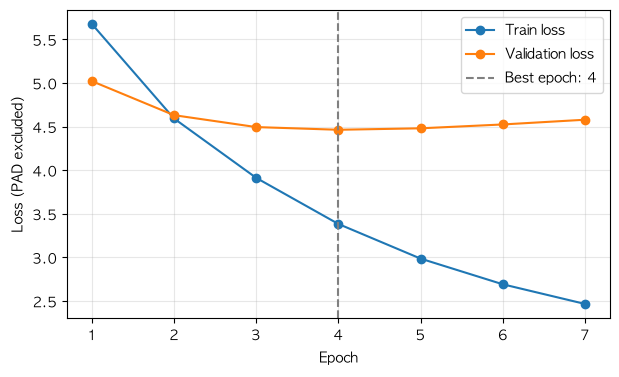

korean,시민들은 도시 속에 산다.,오바마는 대통령이다.,일곱 명의 사망자가 발생했다.,커피는 필요 없다.
epoch,,,,
1,the couple is a very different .,president elect barack obama is expected to be...,the quake was killed in a car bomb in the sout...,there is no indication of the problem .
2,the pair is a little bit .,president obama is expected to be in the white...,the incident occurred in a suicide bombing .,there is no doubt that the bacteria is not a l...
3,the city is a small town of the city .,obama has chosen his lead in the house of lords .,the attack occurred in the attack .,there is no need for the coffee .
4,the mountain is a place where the couple is in...,"obama s president , who was campaigning for pr...",the attack occurred shortly after a grenade .,i don t have a little bit .
5,the mountain is a place where the city of kan ...,"obama s president , who has been campaigning f...",a second mock in the death toll from a second ...,coffee is not a good morning .
6,the mountain is a huge explosion .,obama will pick up the process .,another person was killed in a series of griss...,coffee is a good man .
7,the mountain is the place where the city is lo...,obama will be president barack obama .,the death toll from the storm was killed in a ...,coffee is not a coffee .


K1) 오바마는 대통령이다.
E1) obama s president , who was campaigning for president , was campaigning for his presidency .
K2) 시민들은 도시 속에 산다.
E2) the mountain is a place where the couple is in place .
K3) 커피는 필요 없다.
E3) i don t have a little bit .
K4) 일곱 명의 사망자가 발생했다.
E4) the attack occurred shortly after a grenade .


In [ ]:
if best_epoch == 0:
    print('아직 검증을 마친 에포크가 없습니다. 학습 셀을 실행하세요.')
else:
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch: {best_epoch}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (PAD excluded)')
    plt.legend()
    plt.xticks(range(1, len(train_losses) + 1))
    plt.grid(alpha=0.3)
    plt.show()

    # 각 epoch의 실제 번역을 나란히 보고 의미가 자연스러운 결과를 고릅니다.
    translation_df = pd.DataFrame(translation_history, columns=['epoch', 'example', 'korean', 'translation'])
    display(translation_df.pivot(index='epoch', columns='korean', values='translation'))

    selected_epoch = best_epoch  # 최저 검증 손실의 모델과 같은 시점의 번역 기록입니다.
    selected_results = translation_df[translation_df['epoch'] == selected_epoch]
    # 번역 출력 도중 중단되어 기록이 빠졌다면 복원된 최적 모델로 보완합니다.
    if selected_epoch == best_epoch and len(selected_results) < len(example_sentences):
        recovered_results = []
        for number, sentence in enumerate(example_sentences, start=1):
            result_text, _, _, _ = evaluate(
                sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN
            )
            recovered_results.append({'epoch': best_epoch, 'example': number,
                                      'korean': sentence, 'translation': result_text})
        selected_results = pd.DataFrame(recovered_results)
    for row in selected_results.itertuples():
        print(f'K{row.example}) {row.korean}')
        print(f'E{row.example}) {row.translation}')


## Attention Map(어텐션 맵)

검증 손실이 가장 낮았던 `best_epoch`의 가중치를 복원한 모델로 그립니다. 위에서 `selected_epoch`를 바꾸면 표시할 번역 기록만 바뀌며, 현재 모델은 최적 가중치를 유지합니다.

아래 `example_sentences[0]`을 원하는 한국어 문장 문자열로 바꾸면 새로운 번역과 어텐션 맵을 확인할 수 있습니다.


Input: 오바마는 대통령이다 .
Predicted translation: obama s president , who was campaigning for president , was campaigning for his presidency .


/Users/yongza/300억/PRI_AI/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


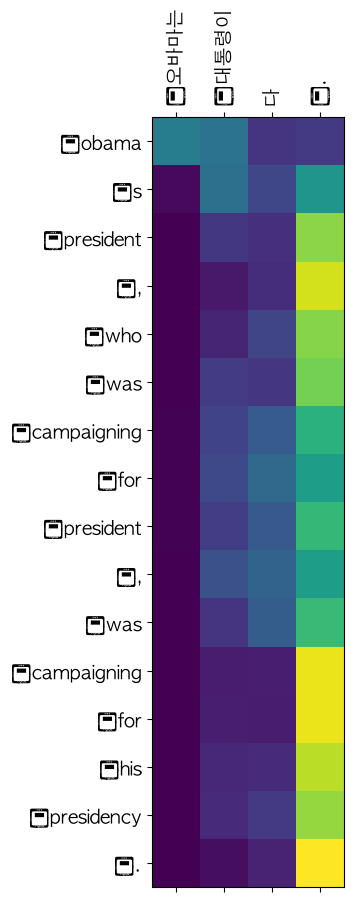

In [ ]:
# 그림이 필요할 때 실행합니다.
translate(example_sentences[0], model, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)


## 1차   
vocab_size = 30000  
MAX_LEN = 50  
BATCH_SIZE = 64  
emb_dim = 256  
hid_dim = 512  
EPOCHS = 50 (37회차에 강제 중단)  
PATIENCE = 3  
MIN_DELTA = 0.001  

Epoch 37: 100%  
1127/1127 [09:29<00:00,  2.05it/s, loss=0.605]  
Epoch 37/50, Train Loss: 0.4506  
K1) 오바마는 대통령이다.  
E1) obama is going to be the president .  
K2) 시민들은 도시 속에 산다.  
E2) in , followed by a city far that followed a smaller invasion .  
K3) 커피는 필요 없다.  
E3) coffee is to do .  
K4) 일곱 명의 사망자가 발생했다.  
E4) sunday s death was accidental .  

**특이점** Epoch 3/50, Train Loss: 3.3560
K3) 커피는 필요 없다.  
E3) caffeine is a good thing .  

---
## 2차  
vocab_size = 20000  
MAX_LEN = 50  
BATCH_SIZE = 64  
emb_dim = 256  
hid_dim = 512  
EPOCHS = 50 (38 회차에서 강제 중단)  
PATIENCE = 3  
MIN_DELTA = 0.001  

Epoch 37/50, Train Loss: 0.5461  
K1) 오바마는 대통령이다.  
E1) obama s campaigning on the president is campaigning in the campaigning .  
K2) 시민들은 도시 속에 산다.  
E2) they re bearing the city s maielze .  
K3) 커피는 필요 없다.  
E3) coffee has no way .  
K4) 일곱 명의 사망자가 발생했다.  
E4) on sunday , seven people were killed .  

**특이점** : Epoch 5/50, Train Loss: 2.3701  
K1) 오바마는 대통령이다.  
E1) obama is the president of the president , and the president .  


---
## 3차

vocab_size = 15000  
MAX_LEN = 30  
BATCH_SIZE = 64  
emb_dim = 512  
hid_dim = 1024  
dropout_rate = 0.3  
EPOCHS = 30  
PATIENCE = 3  
MIN_DELTA = 0.001  

Epoch 30: 100%|██████████| 1127/1127 [06:17<00:00,  2.99it/s, loss=1.42]Epoch 30/30, Train Loss: 1.3649  
K1) 오바마는 대통령이다.  
E1) obama lost his appearance .  
K2) 시민들은 도시 속에 산다.  
E2) locals down the city s place .  
K3) 커피는 필요 없다.  
E3) it is necessary .  
K4) 일곱 명의 사망자가 발생했다.  
E4) seven people were killed . (*)  
학습 완료: 30 epoch, 마지막 모델을 유지합니다.  


---
## 4차
vocab_size = 15000
MAX_LEN = 50  # 아래 잘림 비율 표를 보고 조절합니다.
BATCH_SIZE = 64
emb_dim = 512
hid_dim = 1024
dropout_rate = 0.3

코랩 환경 제한으로 중단

Epoch 6: 100%
 1117/1117 [19:49<00:00,  1.09it/s, loss=3.05]
Epoch 6/30, Train Loss: 2.7470
K1) 오바마는 대통령이다.
E1) obama s inauguration is the first time he has been
K2) 시민들은 도시 속에 산다.
E2) the town of pitched city is located in the city
K3) 커피는 필요 없다.
E3) coffee retailer coffee t have any coffee .
K4) 일곱 명의 사망자가 발생했다.
E4) the shootings occurred about 1 . 2 people .

---
### 5차